## Dataset Overview

In [1]:
# Load necessary libraries
import os
import sys
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)
from train_supervised import load_and_label, CHEATER_PATH, NON_CHEATER_PATH
import pyarrow.parquet as pq

%matplotlib inline
sns.set(style="whitegrid", font_scale=1.1)

project_root = os.path.abspath("..")
results_dir = os.path.join(project_root, "results")

In [2]:
def load_sample_data(n_files=10, rows_per_file=20000):
    cheater_files = [
        os.path.join(CHEATER_PATH, f)
        for f in os.listdir(CHEATER_PATH)
        if f.endswith(".parquet")
    ][:n_files]

    non_cheater_files = [
        os.path.join(NON_CHEATER_PATH, f)
        for f in os.listdir(NON_CHEATER_PATH)
        if f.endswith(".parquet")
    ][:n_files]

    dfs = []
    for file_path, label in [(cheater_files, 1), (non_cheater_files, 0)]:
        for f in file_path:
            try:
                table = pq.read_table(f)
                df = table.to_pandas().head(rows_per_file)
                df["is_cheater"] = label
                df["steamid"] = os.path.basename(f).split(".")[0]
                dfs.append(df)
            except Exception as e:
                print(f"Skipped {f}: {e}")

    return pd.concat(dfs, ignore_index=True)

df = load_sample_data()

## Load Models and Files

In [3]:
rf = joblib.load(os.path.join(results_dir, "random_forest_model.pkl"))
lr = joblib.load(os.path.join(results_dir, "logistic_regression_model.pkl"))

X_test = pd.read_csv(os.path.join(results_dir, "X_test.csv"))
y_test = pd.read_csv(os.path.join(results_dir, "y_test.csv"))

X_val = pd.read_csv(os.path.join(results_dir, "X_val.csv"))
y_val = pd.read_csv(os.path.join(results_dir, "y_val.csv")).values.ravel()

## Predictions and Probabilities

In [4]:
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

## Data Visualizations

### Classification Reports

In [5]:
print(classification_report(y_test, lr_pred))
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



### Confusion Matrix

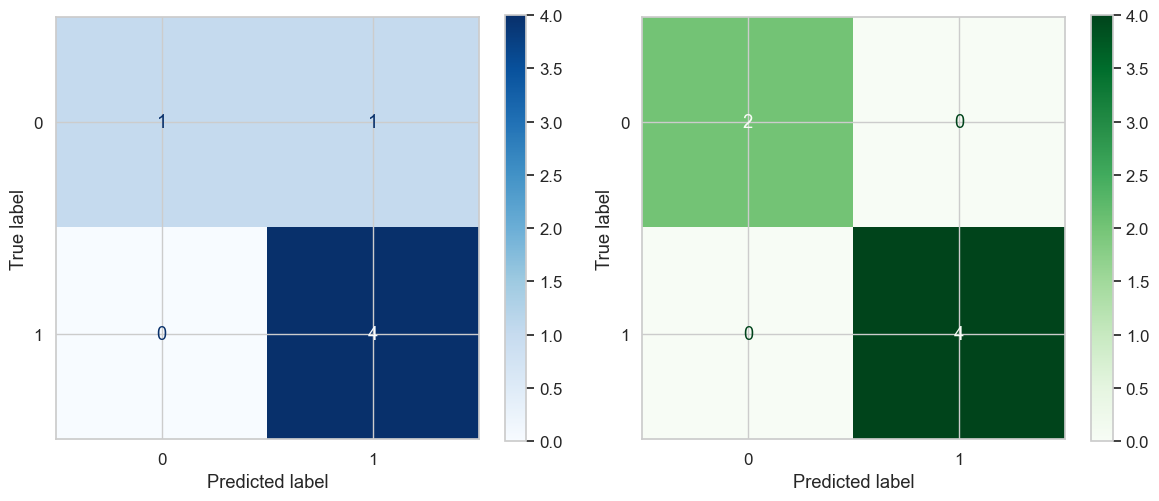

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, 
                                                ax=ax[0], 
                                                cmap="Blues",
                                                values_format='d')
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, 
                                        ax=ax[1], 
                                        cmap="Greens",
                                        values_format='d')

plt.tight_layout()
plt.show()

### ROC Curves

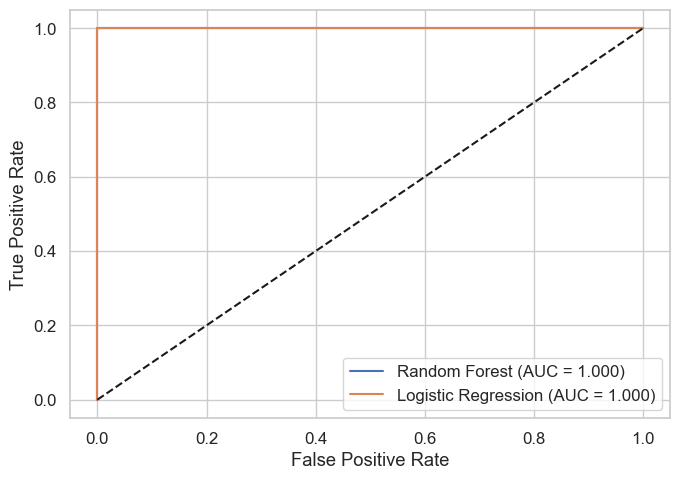

In [7]:
plt.figure(figsize=(7,5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.3f})".format(auc(fpr_rf, tpr_rf)))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = {:.3f})".format(auc(fpr_lr, tpr_lr)))
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance - Random Forest

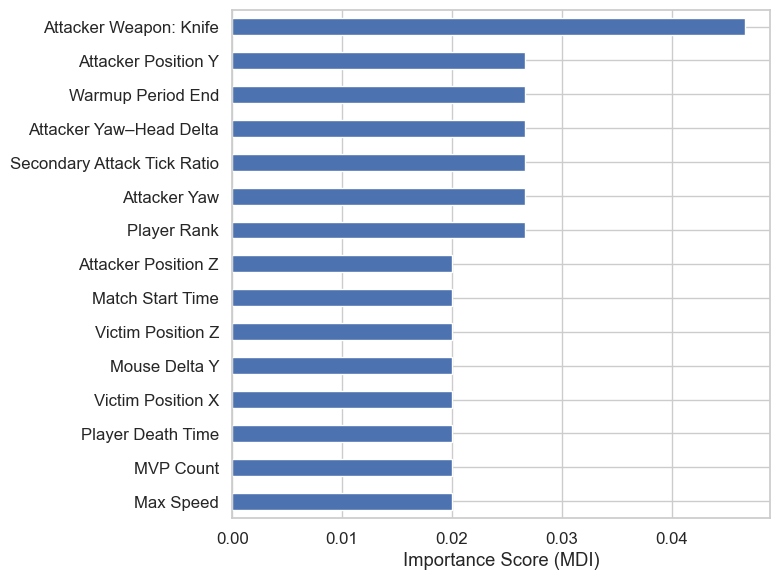

In [8]:
rename_columns = {
    "a_t_t_a_c_k_e_r___w_e_a_p_o_n___k_n_i_f_e": "Attacker Weapon: Knife",
    "a_t_t_a_c_k_e_r___Y": "Attacker Position Y",
    "w_a_r_m_u_p___p_e_r_i_o_d___e_n_d": "Warmup Period End",
    "a_t_t_a_c_k_e_r___y_a_w___h_e_a_d___d_e_l_t_a": "Attacker Yaw–Head Delta",
    "n_e_x_t___s_e_c_o_n_d_a_r_y___a_t_t_a_c_k___t_i_c_k___r_a_t_i_o": "Secondary Attack Tick Ratio",
    "a_t_t_a_c_k_e_r___y_a_w": "Attacker Yaw",
    "r_a_n_k": "Player Rank",
    "a_t_t_a_c_k_e_r___Z": "Attacker Position Z",
    "m_a_t_c_h___s_t_a_r_t___t_i_m_e": "Match Start Time",
    "v_i_c_t_i_m___Z": "Victim Position Z",
    "u_s_e_r_c_m_d___m_o_u_s_e___d_y": "Mouse Delta Y",
    "v_i_c_t_i_m___X": "Victim Position X",
    "d_e_a_t_h___t_i_m_e": "Player Death Time",
    "m_v_p_s": "MVP Count",
    "m_a_x___s_p_e_e_d": "Max Speed"
}

clean_columns = X_test.columns.to_series().replace(rename_columns)
importances = pd.Series(rf.feature_importances_, index=clean_columns)

plt.figure(figsize=(8,6))
importances.sort_values().tail(15).plot(kind="barh")
plt.xlabel("Importance Score (MDI)")
plt.tight_layout()
plt.show()

### Bar Charts

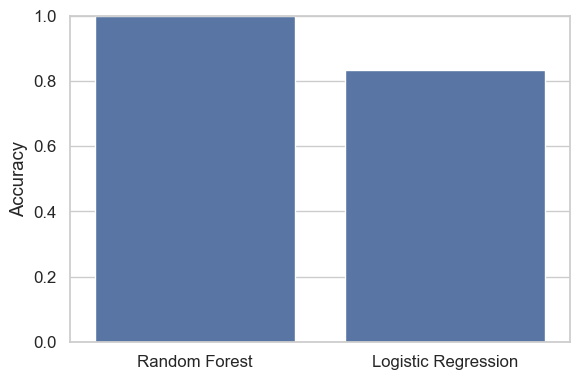

In [64]:
import numpy as np
rf_pred = np.array(rf_pred).ravel()
lr_pred = np.array(lr_pred).ravel()
y_test = np.array(y_test).ravel()
accuracies = {
    "Random Forest": (rf_pred == y_test).mean(),
    "Logistic Regression": (lr_pred == y_test).mean(),
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()